# Visualize Shanghai Radar data

In [2]:
import torch
import h5py
import numpy as np
from torch.utils.data import Dataset
from torchvision import transforms 
from matplotlib import colors
# from src.data_shanghai import Shanghai, gray2color
import matplotlib.pyplot as plt

In [2]:
PIXEL_SCALE = 90.0

COLOR_MAP = np.array([
    [0, 0, 0,0],
    [0, 236, 236, 255],
    [1, 160, 246, 255],
    [1, 0, 246, 255],
    [0, 239, 0, 255],
    [0, 200, 0, 255],
    [0, 144, 0, 255],
    [255, 255, 0, 255],
    [231, 192, 0, 255],
    [255, 144, 2, 255],
    [255, 0, 0, 255],
    [166, 0, 0, 255],
    [101, 0, 0, 255],
    [255, 0, 255, 255],
    [153, 85, 201, 255],
    [255, 255, 255, 255]
    ]) / 255

BOUNDS = [0,5,10,15,20,25,30,35,40,45,50,55,60,65,70,75, PIXEL_SCALE]
THRESHOLDS = [20, 30, 35, 40]

HMF_COLORS = np.array([
    [82, 82, 82],
    [252, 141, 89],
    [255, 255, 191],
    [145, 191, 219]
]) / 255

/pscratch/sd/p/puren93/miniforge3.bak-20250811-1035/envs/sft/lib/python3.10/site-packages/torchvision/transforms/functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


1545
torch.Size([25, 1, 128, 128]) torch.Size([25, 1, 128, 128])
tensor(0.) tensor(0.8307)
tensor(0.) tensor(0.7082)


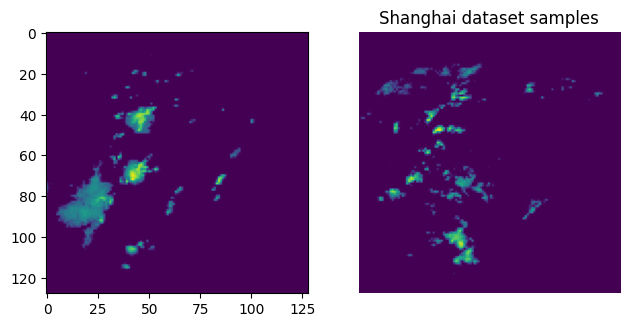

In [ ]:
data_path = "/global/cfs/cdirs/m4633/puren/interp_dm/shanghai/"
dataset = Shanghai(data_path + 'shanghai.h5', 128)
sample1 = dataset.sample()
sample2 = dataset.sample()

print(len(dataset))
print(sample1.shape, sample2.shape)
print(sample1.min(), sample1.max())
print(sample2.min(), sample2.max())
# print(sample1[0,0].numpy())

# plt.subplot(1,2,1)
# plt.imshow(sample1[10,0].numpy())
# plt.subplot(1,2,2)
# plt.imshow(sample2[10,0].numpy())
# # plt.title('Shanghai dataset samples')
# plt.tight_layout()
# # plt.axis('off')
# plt.colormaps()
# plt.show()
# # plt.savefig('sample.png')

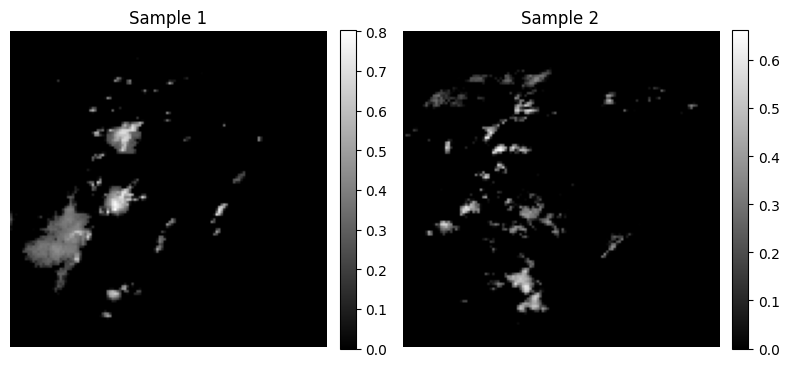

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
cmap = 'gray' # 'turbo' # 'viridis' #  

# First subplot
im1 = axes[0].imshow(sample1[10, 0].numpy(), cmap=cmap)
axes[0].set_title('Sample 1')
axes[0].axis('off')
fig.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)

# Second subplot
im2 = axes[1].imshow(sample2[10, 0].numpy(), cmap=cmap)
axes[1].set_title('Sample 2')
axes[1].axis('off')
fig.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
# plt.savefig('sample.png', dpi=300, bbox_inches='tight')
plt.show()

In [12]:
# fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# # First subplot
# im1 = axes[0].imshow(gray2color(sample1[10, 0].numpy()), cmap='viridis')
# axes[0].set_title('Sample 1')
# axes[0].axis('off')
# fig.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)

# # Second subplot
# im2 = axes[1].imshow(gray2color(sample2[10, 0].numpy()), cmap='viridis')
# axes[1].set_title('Sample 2')
# axes[1].axis('off')
# fig.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)

# plt.tight_layout()
# # plt.savefig('sample.png', dpi=300, bbox_inches='tight')
# plt.show()

# Visualize NSKT data

In [1]:
# import torch
import h5py
import numpy as np
# from torch.utils.data import Dataset
# from torchvision import transforms 
from matplotlib import colors
# from src.data_shanghai import Shanghai, gray2color
import matplotlib.pyplot as plt
import os
import cmocean
import seaborn as sns

In [2]:
# define the Reynolds numbers for train and eval
RE_EVAL_LIST = [
    600, 1000, 2000, 4000, 8000, 
    12000, 16000, 24000, 32000, 36000
]

re = RE_EVAL_LIST[-1]
seed = '3407'
scratch_dir = '/global/cfs/cdirs/m4633/foundationmodel/nskt_tensor/'
path = os.path.join(
                scratch_dir,
                f"{re}_2048_2048_seed_{seed}.h5"
            )

data = h5py.File(path, 'r')['w']
print(data.shape)

(1501, 2048, 2048)


time index: 700
time index: 750
time index: 800


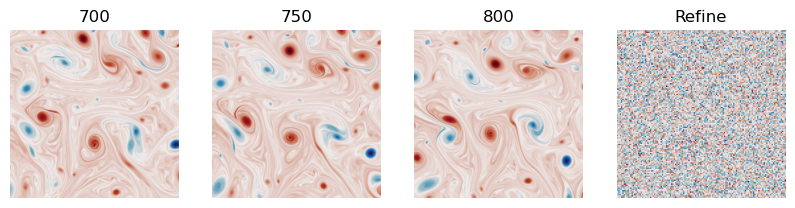

In [9]:
ncol = 4 # 3
nrow = 1
start = 700
patch_start = 0
icefire_cmap = sns.color_palette('icefire', as_cmap=True)
# cmap = icefire_cmap # cmocean.cm.balance
cmap = cmocean.cm.balance

time_idx_list = []
# f, axarr = plt.subplots(ncol, nrow, figsize = (3, 10)) # (3, 8)
f, axarr = plt.subplots(nrow, ncol, figsize = (10, 3)) # (3, 8)
for i in range(ncol): 
    if i < ncol - 1:
        time_idx = start + i * 50
        time_idx_list.append(time_idx)
        print(f"time index: {time_idx}")

        axarr[i].imshow(
            data[time_idx, patch_start : patch_start + 1024, patch_start : patch_start + 1024], 
            # data[time_idx, :, :],
            cmap = cmap
        )
        axarr[i].set_xticks([])
        axarr[i].set_yticks([])
        axarr[i].title.set_text(str(time_idx)) 
        axarr[i].axis('off')

    elif i == (ncol - 1):
        # start = data[time_idx_list[0], patch_start : patch_start + 1024, patch_start : patch_start + 1024]
        # end = data[time_idx_list[-1], patch_start : patch_start + 1024, patch_start : patch_start + 1024]
        # # true = data[time_idx_list[1], patch_start : patch_start + 1024, patch_start : patch_start + 1024]
        # # refine = (start + end) / 2 - true
        # refine = (start + end) / 2
        refine = np.random.randn(128, 128)

        axarr[i].imshow(
            refine, 
            # data[time_idx, :, :],
            cmap = cmap
        )
        axarr[i].set_xticks([])
        axarr[i].set_yticks([])
        axarr[i].title.set_text('Refine') 
        axarr[i].axis('off')

plt.savefig('nskt_sample_2.png', dpi=300, bbox_inches='tight')

time index: 720
time index: 740
time index: 760
time index: 780


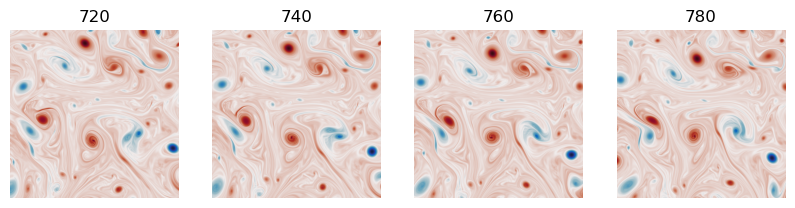

In [4]:
ncol = 4
nrow = 1
start = 720 # 700
patch_start = 0
# icefire_cmap = sns.color_palette('icefire', as_cmap=True)
# cmap = icefire_cmap # cmocean.cm.balance
cmap = cmocean.cm.balance

time_idx_list = []
# f, axarr = plt.subplots(ncol, nrow, figsize = (3, 10)) # (3, 8)
f, axarr = plt.subplots(nrow, ncol, figsize = (10, 3)) # (3, 8)
for i in range(ncol): 

    time_idx = start + i * 20
    time_idx_list.append(time_idx)
    print(f"time index: {time_idx}")

    axarr[i].imshow(
        data[time_idx, patch_start : patch_start + 1024, patch_start : patch_start + 1024], 
        # data[time_idx, :, :],
        cmap = cmap
    )
    axarr[i].set_xticks([])
    axarr[i].set_yticks([])
    axarr[i].title.set_text(str(time_idx)) 
    axarr[i].axis('off')


    # start = data[time_idx_list[0], patch_start : patch_start + 1024, patch_start : patch_start + 1024]
    # end = data[time_idx_list[-1], patch_start : patch_start + 1024, patch_start : patch_start + 1024]
    # # true = data[time_idx_list[1], patch_start : patch_start + 1024, patch_start : patch_start + 1024]
plt.savefig('nskt_sample_3.png', dpi=300, bbox_inches='tight')

In [ ]:
ncol = 3
nrow = 1
start = 700
patch_start = 0
icefire_cmap = sns.color_palette('icefire', as_cmap=True)
# cmap = icefire_cmap # cmocean.cm.balance
cmap = cmocean.cm.balance

# random_noise = torch.randn(n_sample, *size)
random_noise = np.random.randn(1024, 1024)


f, axarr = plt.subplots(ncol, nrow, figsize = (3, 8))
for i in range(ncol): 
    time_idx = start + i * 50
    axarr[i].imshow(
        data[time_idx, patch_start : patch_start + 1024, patch_start : patch_start + 1024], 
        # data[time_idx, :, :],
        cmap = cmap
    )
    axarr[i].set_xticks([])
    axarr[i].set_yticks([])
    axarr[i].title.set_text(str(time_idx)) 
    axarr[i].axis('off')

plt.savefig('nskt_sample.png', dpi=300, bbox_inches='tight')

# Visualize era5 data

In [1]:
import os
import torch
from torch.utils.data import Dataset
from datetime import timedelta, datetime
import numpy as np
import pickle
import numpy as np
from matplotlib import colors
import matplotlib.pyplot as plt
import os
import cmocean
import seaborn as sns

class InputHandle(Dataset):
    def __init__(self, input_param):
        self.path = input_param['path']
        self.input_data_type = input_param.get('input_data_type', 'float32')
        self.length = input_param['total_length']*2
        self.input_length = input_param['input_length']*2
        self.type = input_param['type'] #train/test/valid
        self.mean = np.load('./datasets/mean_z500.npy')

        try:
            with open(os.path.join(self.path, self.type+'.pkl'), 'rb') as f:
                obj = pickle.load(f)
            self.path_list = obj['path_list']
            print(len(self.path_list), 'indices found in', os.path.join(self.path, self.type + '.pkl'))
        except:
            time_list = []
            file_list = []
            self.path_list = []
            years = os.listdir(self.path)
            years.sort()
            for year in years:
                year_path = os.path.join(self.path, year)
                if not os.path.isdir(year_path):
                    continue
                days = os.listdir(year_path)
                days.sort()
                for day in days:
                    day_path = os.path.join(year_path, day)
                    if not os.path.isdir(day_path):
                        continue
                    hours = os.listdir(day_path)
                    hours.sort()
                    for hour in hours:
                        if 'npy' in hour:
                            file_list.append(os.path.join(day_path, hour))
                            time_list.append(day+hour[-8:-4])
            for i in range(len(time_list)):
                if i + self.length - 1 >= len(time_list):
                    break
                cur_time = datetime.strptime(time_list[i], '%Y%m%d%H%M')
                next_time = datetime.strptime(time_list[i + self.length - 1], '%Y%m%d%H%M')
                if cur_time + timedelta(hours=(self.length-1)*3) == next_time:
                    if next_time.year < 2013 or cur_time.year < 2013:
                        continue
                    if self.type == 'train' and next_time.year <= 2019 and cur_time.year <= 2019:
                        self.path_list.append([file_list[i+j] for j in range(self.length)])
                    elif self.type == 'valid' and next_time.year == 2020 and cur_time.year == 2020:
                        self.path_list.append([file_list[i+j] for j in range(self.length)])
                    elif self.type == 'test' and next_time.year >= 2021 and cur_time.year >= 2021:
                        self.path_list.append([file_list[i+j] for j in range(self.length)])
            with open(os.path.join(self.path, self.type + '.pkl'), 'wb') as f:
                pickle.dump({'path_list':self.path_list,'time_list':time_list}, f)
            print(len(time_list), 'imgs found,', len(self.path_list), 'indices saved in', os.path.join(self.path, self.type + '.pkl'))

    def __len__(self):
        return len(self.path_list)

    def __getitem__(self, index):
        npy_paths = self.path_list[index]
        data = []
        for npy_path in npy_paths:
            data.append(np.load(npy_path))
        data = np.stack(data, axis=-1).astype(self.input_data_type) - np.expand_dims(self.mean, axis=-1)
        print("data shape is: ", data.shape)
        
        input_data = data[..., :self.input_length]
        if self.type == 'train':
            output_data = data[..., self.input_length:self.length]
        else:
            output_data = data[..., self.input_length:]
        return input_data[..., ::2], output_data[..., ::2]

In [2]:

data_dir = '/global/cfs/projectdirs/m4633/puren/interp_dm/z500_era5/'
T_in =2
T_out = 10
input_param = {
    'path': data_dir,
    'total_length': T_in+T_out,
    'input_length': T_in,
    'type': 'train'
}

dataset = InputHandle(input_param)
index = 1
input_data, output_data = dataset[index]
print(input_data.shape, output_data.shape)
print(input_data.min(), input_data.max())

20425 indices found in /global/cfs/projectdirs/m4633/puren/interp_dm/z500_era5/train.pkl
data shape is:  (72, 144, 24)
(72, 144, 2) (72, 144, 10)
-5025.258 3496.3945


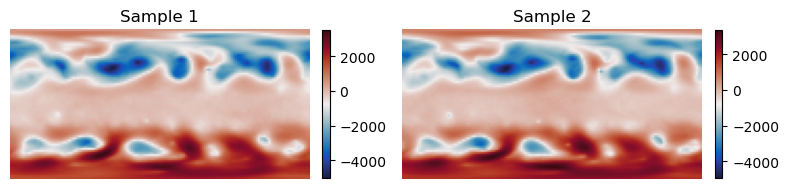

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
# cmap = 'gray' # 'turbo' # 'viridis' #  
cmap = cmocean.cm.balance

# First subplot
im1 = axes[0].imshow(input_data[:,:,0], cmap=cmap)
axes[0].set_title('Sample 1')
axes[0].axis('off')
fig.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04, shrink=0.4)

# Second subplot
im2 = axes[1].imshow(input_data[:, :, 1], cmap=cmap)
axes[1].set_title('Sample 2')
axes[1].axis('off')
fig.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04, shrink=0.4)

plt.tight_layout()
# plt.savefig('sample.png', dpi=300, bbox_inches='tight')
plt.show()

# Visualize the sea surface data

In [11]:
import os

from torch.utils.data import Dataset
from datetime import timedelta, datetime
import numpy as np
import pickle
import cv2

from matplotlib import colors
import matplotlib.pyplot as plt
import os
import cmocean
import seaborn as sns


class InputHandle(Dataset):
    def __init__(self, input_param):
        self.path = input_param['path']
        self.train_path = [self.path + '/' + dir_path for dir_path in ['data_atlantic_south', 'data_indian', 'data_northpacific']]
        self.valid_path = [self.path + '/' + dir_path for dir_path in ['data_atlantic_south', 'data_indian', 'data_northpacific']]
        self.test_path = [self.path + '/' + dir_path for dir_path in ['data_southpacific_new']]
        self.path_dict = {
            'train': self.train_path,
            'valid': self.valid_path,
            'test': self.test_path,
        }
        self.patch_position = {
            # 'data_atlantic': [(i,j) for i in range(7,11) for j in range(3)],
            'data_indian': [(i,j) for i in range(3) for j in range(3)],
            'data_northpacific': [(i,j) for i in range(3) for j in range(3)],
            # 'data_southpacific': [(i,j) for i in range(3) for j in range(3)],
            'data_atlantic_south': [(i,j) for i in range(3) for j in range(3)],
            'data_southpacific_new': [(i,j) for i in range(3) for j in range(3)],
        }
        self.patch_position['data_indian'].remove((2,0))
        self.latitude_map = {}
        self.longitude_map = {}
        self.input_data_type = input_param.get('input_data_type', 'float32')
        self.length = input_param['total_length']
        self.input_length = input_param['input_length']
        self.type = input_param['type'] #train/test/valid

        try:
            with open(os.path.join(self.path, 'sea_temperature' + self.type + '.pkl'), 'rb') as f:
                obj = pickle.load(f)
            self.path_list = obj['path_list']
            self.position_list = obj['position']
            self.latitude_map = obj['latitude']
            self.longitude_map = obj['longitude']
            # assert 1 == 0
            print(len(self.path_list), 'indices found in', os.path.join(self.path, 'sea_temperature' + self.type + '.pkl'))
        except:
            self.path_list = []
            self.position_list = []
            for dir_path in self.path_dict[self.type]:
                position = dir_path.split('/')[-1]
                # print(dir_path)
                self.latitude_map[position] = np.load(os.path.join(dir_path, 'latitude.npy'))
                self.longitude_map[position] = np.load(os.path.join(dir_path, 'longitude.npy'))
                time_list = []
                file_list = []
                dir_path = os.path.join(dir_path, 'temperature_npy')
                years = os.listdir(dir_path)
                years.sort()
                for year in years:
                    year_path = os.path.join(dir_path, year)
                    if not os.path.isdir(year_path):
                        continue
                    days = os.listdir(year_path)
                    days.sort()
                    for day in days:
                        if '.npy' not in day:
                            continue
                        day_path = os.path.join(year_path, day)
                        file_list.append(day_path)
                        print("day length is: ", len(day))
                        time_list.append(day[-12:-4])
                for i in range(len(time_list)):
                    if i + self.length - 1 >= len(time_list):
                        break
                    cur_time = datetime.strptime(time_list[i], '%Y%m%d')
                    next_time = datetime.strptime(time_list[i + self.length - 1], '%Y%m%d')
                    if cur_time + timedelta(days=(self.length-1)) == next_time:
                        if self.type == 'train' and next_time.year <= 2018 and cur_time.year <= 2018:
                            for k in range(len(self.patch_position[position])):
                                self.path_list.append([file_list[i+j] for j in range(self.length)])
                                self.position_list.append(self.patch_position[position][k])
                        elif self.type == 'valid' and next_time.year > 2018 and cur_time.year > 2018:
                            for k in range(len(self.patch_position[position])):
                                self.path_list.append([file_list[i+j] for j in range(self.length)])
                                self.position_list.append(self.patch_position[position][k])
                        elif self.type == 'test':# and next_time.year >= 2021 and cur_time.year >= 2021:
                            for k in range(len(self.patch_position[position])):
                                self.path_list.append([file_list[i+j] for j in range(self.length)])
                                self.position_list.append(self.patch_position[position][k])
            with open(os.path.join(self.path, 'sea_temperature' + self.type + '.pkl'), 'wb') as f:
                pickle.dump({'path_list':self.path_list,'time_list':time_list,'position': self.position_list,
                             'latitude': self.latitude_map, 'longitude': self.longitude_map}, f)
            print(len(time_list), 'imgs found,', len(self.path_list), 'indices saved in', os.path.join(self.path, 'sea_temperature' + self.type + '.pkl'))

    def __len__(self):
        return len(self.path_list)

    def __getitem__(self, index):
        npy_paths = self.path_list[index]
        position = self.position_list[index]
        lat = self.latitude_map[npy_paths[0].split('/')[-4]][position[0] * 60:position[0] * 60 + 128]
        lon = self.longitude_map[npy_paths[0].split('/')[-4]][position[1] * 60:position[1] * 60 + 128]
        lat = np.array([lat[0] + (j * (lat[-1] - lat[0]) / 63.5) for j in range(64)])
        lon = np.array([lon[0] + (j * (lon[-1] - lon[0]) / 63.5) for j in range(64)])

        coor1, coor2 = np.meshgrid(lat, lon)
        coor = np.stack((coor1, coor2))
        coor_data = np.concatenate([np.sin(coor), np.cos(coor)], axis=0).astype(self.input_data_type).transpose(1, 2, 0)

        time_list = []
        data = []
        print("length of npy_paths is: ", len(npy_paths))
        print("one npy sample shape is : ", np.load(npy_paths[0]).shape)
        for i in range(self.length):
            npy_path = npy_paths[i]
            npy = np.load(npy_path)

            # npy = npy[:, (position[0] * 60) : (position[0] * 60 + 128), (position[1] * 60) : (position[1] * 60 + 128)]
            # data.append(cv2.resize(npy[0], (64, 64)))
            npy = npy[:, (position[0] * 60) : (position[0] * 60 + 256), (position[1] * 60) : (position[1] * 60 + 256)]
            data.append(cv2.resize(npy[0], (128, 128)))

            cur_time = npy_path.split('/')[-1][:-4]
            cur_day = datetime.strptime(cur_time, '%Y%m%d')
            cur_day = cur_day.timetuple().tm_yday
            t = np.expand_dims(np.array([np.sin(cur_day / 366), np.cos(cur_day / 366)]), 1)
            time_list.append(t)
        data = np.stack(data, axis=0).astype(self.input_data_type)
        print('data shape before transpose: ', data.shape)

        time_data = np.concatenate(time_list, axis=1).astype(self.input_data_type)
        data = data.transpose((1,2,0))
        # print(data.shape)
        input_data = data[..., :self.input_length]
        output_data = data[..., self.input_length:]
        return input_data, output_data, time_data, coor_data

In [13]:
data_dir = '/global/cfs/projectdirs/m4633/puren/interp_dm/sea_temp/'
T_in = 2
T_out = 10
input_param = {
    'path': data_dir,
    'total_length': T_in + T_out,
    'input_length': T_in,
    'type': 'train'
}

dataset = InputHandle(input_param)
index = 1
input_data, output_data, time_data, coor_data = dataset[index]

print(input_data.shape, output_data.shape)
print(input_data.min(), input_data.max())

172241 indices found in /global/cfs/projectdirs/m4633/puren/interp_dm/sea_temp/sea_temperaturetrain.pkl
length of npy_paths is:  12
one npy sample shape is :  (1, 253, 253)
data shape before transpose:  (12, 128, 128)
(128, 128, 2) (128, 128, 10)
7.830814 25.679836


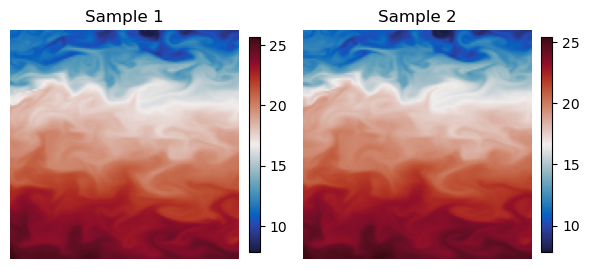

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
# cmap = 'gray' # 'turbo' # 'viridis' #  
cmap = cmocean.cm.balance

# First subplot
im1 = axes[0].imshow(input_data[:,:,0], cmap=cmap)
axes[0].set_title('Sample 1')
axes[0].axis('off')
fig.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04, shrink=0.8)

# Second subplot
im2 = axes[1].imshow(input_data[:, :, 1], cmap=cmap)
axes[1].set_title('Sample 2')
axes[1].axis('off')
fig.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04, shrink=0.8)

plt.tight_layout()
# plt.savefig('sample.png', dpi=300, bbox_inches='tight')
plt.show()